# TAHAP 03 — Dataset Expansion, FAQ Enrichment, dan Improvement Chatbot Response

Tahapan untuk memperluas dataset FAQ chatbot MTI UNPAM, memperkaya variasi pertanyaan, menambahkan contoh out-of-scope, melakukan evaluasi ulang, membandingkan performa sebelum dan sesudah dataset expansion, serta menghasilkan visualisasi improvement.

## 1. Business Understanding

Tujuan tahap ini adalah meningkatkan kualitas chatbot berbasis FAQ, TF-IDF, dan Cosine Similarity agar mampu menjawab lebih banyak variasi pertanyaan calon mahasiswa. Fokus improvement meliputi perluasan dataset FAQ, perbaikan jawaban, penguatan fallback, evaluasi ulang, dan dokumentasi hasil.

In [3]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# Deteksi root project secara otomatis.
# Jika notebook dijalankan dari folder notebooks/, dataset tetap dicari ke ../data/.
CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / "data" / "faq_mti_unpam.csv").exists():
    PROJECT_ROOT = CURRENT_DIR
elif CURRENT_DIR.name.lower() == "notebooks" and (CURRENT_DIR.parent / "data" / "faq_mti_unpam.csv").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    candidates = [CURRENT_DIR] + list(CURRENT_DIR.parents)
    PROJECT_ROOT = next(
        (path for path in candidates if (path / "data" / "faq_mti_unpam.csv").exists()),
        CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR
    )

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "stage03"
FIG_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

FAQ_PATH = DATA_DIR / "faq_mti_unpam.csv"
EVAL_PATH = DATA_DIR / "evaluation_questions.csv"

if not FAQ_PATH.exists():
    raise FileNotFoundError(f"File FAQ tidak ditemukan: {FAQ_PATH}")
if not EVAL_PATH.exists():
    raise FileNotFoundError(f"File evaluasi tidak ditemukan: {EVAL_PATH}")

print("Current directory:", CURRENT_DIR)
print("Project root:", PROJECT_ROOT)
print("FAQ path:", FAQ_PATH)
print("Evaluation path:", EVAL_PATH)

Current directory: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\TUGAS-21\mti-unpam-academic-chatbot\notebooks
Project root: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\TUGAS-21\mti-unpam-academic-chatbot
FAQ path: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\TUGAS-21\mti-unpam-academic-chatbot\data\faq_mti_unpam.csv
Evaluation path: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\TUGAS-21\mti-unpam-academic-chatbot\data\evaluation_questions.csv


## 2. Data Understanding

Pada tahap ini, dataset FAQ sudah diperluas dari 34 baris menjadi sekitar 75–100 baris. Dataset evaluasi juga diperluas agar pengujian tidak bias hanya pada sedikit pertanyaan.

In [4]:
faq_df = pd.read_csv(FAQ_PATH).fillna("")
eval_df = pd.read_csv(EVAL_PATH).fillna("")

print("FAQ shape:", faq_df.shape)
print("Evaluation shape:", eval_df.shape)
print("FAQ columns:", faq_df.columns.tolist())
print("Evaluation columns:", eval_df.columns.tolist())

faq_df.head()

FAQ shape: (100, 6)
Evaluation shape: (47, 2)
FAQ columns: ['question', 'answer', 'category', 'semester', 'peminatan', 'source_type']
Evaluation columns: ['test_question', 'expected_category']


,question,answer,category,semester,peminatan,source_type
0,Apa itu Program Magister Teknik Informatika UN...,Program Magister Teknik Informatika UNPAM adal...,profil_program,,,manual
1,Apa tujuan chatbot MTI UNPAM Academic Assistant?,Chatbot ini dibuat sebagai media bantu informa...,profil_program,,,manual
2,Apa saja mata kuliah Semester 1 MTI UNPAM?,Mata kuliah Semester I terdiri dari Algoritma ...,kurikulum_semester_1,1.0,,user_provided
3,Apa yang dipelajari pada Algoritma Analisis?,Algoritma Analisis membahas konsep perancangan...,kurikulum_semester_1,1.0,,manual
4,Apa yang dipelajari pada Data Mining?,"Data Mining membahas proses menemukan pola, hu...",kurikulum_semester_1,1.0,,manual


In [5]:
# Distribusi kategori FAQ
faq_category_counts = faq_df["category"].value_counts().reset_index()
faq_category_counts.columns = ["category", "count"]
faq_category_counts

,category,count
0,rekomendasi_peminatan,16
1,kurikulum_semester_2,12
2,kurikulum_semester_1,12
3,peminatan_data_science,11
4,peminatan_iot,10
5,peminatan_data_security,10
6,fallback,8
7,tesis,7
8,profil_program,6
9,prospek_karier,5


## 3. Data Validation

Validasi sederhana dilakukan untuk memastikan kolom wajib tersedia, tidak ada pertanyaan kosong, tidak ada jawaban kosong, dan tidak ada duplikasi pertanyaan.

In [6]:
required_faq_columns = ["question", "answer", "category", "semester", "peminatan", "source_type"]
required_eval_columns = ["test_question", "expected_category"]

faq_missing_cols = [col for col in required_faq_columns if col not in faq_df.columns]
eval_missing_cols = [col for col in required_eval_columns if col not in eval_df.columns]

validation_summary = {
    "faq_missing_columns": faq_missing_cols,
    "eval_missing_columns": eval_missing_cols,
    "faq_empty_questions": int((faq_df["question"].astype(str).str.strip() == "").sum()),
    "faq_empty_answers": int((faq_df["answer"].astype(str).str.strip() == "").sum()),
    "faq_duplicate_questions": int(faq_df.duplicated(subset=["question"]).sum()),
    "eval_empty_questions": int((eval_df["test_question"].astype(str).str.strip() == "").sum()),
    "eval_duplicate_questions": int(eval_df.duplicated(subset=["test_question"]).sum()),
}

validation_summary

{'faq_missing_columns': [],
 'eval_missing_columns': [],
 'faq_empty_questions': 0,
 'faq_empty_answers': 0,
 'faq_duplicate_questions': 0,
 'eval_empty_questions': 0,
 'eval_duplicate_questions': 0}

## 4. Text Preprocessing dan TF-IDF Engine

Preprocessing dibuat sederhana agar mudah dijelaskan secara akademik: lowercase, menghapus karakter non-alfanumerik, dan merapikan spasi. Representasi teks menggunakan TF-IDF dengan unigram dan bigram.

In [7]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

vectorizer = TfidfVectorizer(
    preprocessor=preprocess_text,
    ngram_range=(1, 2),
    min_df=1,
    token_pattern=r"(?u)\b\w+\b",
)

tfidf_matrix = vectorizer.fit_transform(faq_df["question"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (100, 570)


## 5. Fungsi Chatbot Response Tahap 03

Perbaikan utama pada fungsi response adalah penggunaan threshold 0.31 dan perlakuan khusus untuk FAQ dengan kategori `fallback`, sehingga pertanyaan out-of-scope yang eksplisit tetap diperlakukan sebagai fallback.

In [8]:
DEFAULT_THRESHOLD = 0.31

def chatbot_response(user_question, threshold=DEFAULT_THRESHOLD):
    if not str(user_question).strip():
        return {
            "answer": "Silakan masukkan pertanyaan terlebih dahulu.",
            "category": "empty_input",
            "similarity_score": 0.0,
            "matched_question": "",
            "status": "empty",
        }

    user_vector = vectorizer.transform([user_question])
    scores = cosine_similarity(user_vector, tfidf_matrix).flatten()
    best_index = int(scores.argmax())
    best_score = float(scores[best_index])
    selected = faq_df.iloc[best_index]

    fallback_answer = (
        "Maaf, saya belum memiliki informasi yang cukup untuk menjawab pertanyaan tersebut. "
        "Silakan ajukan pertanyaan seputar Program MTI UNPAM, kurikulum, peminatan, tesis, atau prospek karier."
    )

    if best_score < threshold:
        return {
            "answer": fallback_answer,
            "category": "fallback",
            "similarity_score": round(best_score, 4),
            "matched_question": selected["question"],
            "status": "fallback",
        }

    if selected["category"] == "fallback":
        return {
            "answer": selected["answer"],
            "category": "fallback",
            "similarity_score": round(best_score, 4),
            "matched_question": selected["question"],
            "status": "fallback",
        }

    return {
        "answer": selected["answer"],
        "category": selected["category"],
        "similarity_score": round(best_score, 4),
        "matched_question": selected["question"],
        "status": "answered",
    }

# Contoh pengujian cepat
for q in [
    "Saya ingin menjadi data analyst cocok ambil apa?",
    "Semester dua belajar apa?",
    "Bagaimana cara membuat nasi goreng?",
]:
    print("Q:", q)
    print(chatbot_response(q))
    print("-" * 80)

Q: Saya ingin menjadi data analyst cocok ambil apa?
{'answer': 'Untuk target menjadi data analyst, peminatan Data Science paling relevan karena berhubungan dengan pengolahan data, statistik, visualisasi, dashboard, machine learning dasar, dan penyusunan insight berbasis data.', 'category': 'rekomendasi_peminatan', 'similarity_score': 0.5052, 'matched_question': 'Apa peminatan yang cocok untuk menjadi data analyst?', 'status': 'answered'}
--------------------------------------------------------------------------------
Q: Semester dua belajar apa?
{'answer': 'Semester II mencakup Statistic and Data Analysis, Audit dan Tata Kelola IT, Advanced Intelligent Systems, serta Metode Penelitian. Semester ini memperkuat kemampuan analisis data, AI, tata kelola, dan persiapan riset tesis.', 'category': 'kurikulum_semester_2', 'similarity_score': 0.4668, 'matched_question': 'Semester dua MTI UNPAM mempelajari apa saja?', 'status': 'answered'}
--------------------------------------------------------

## 6. Evaluasi Ulang

Evaluasi dilakukan dengan membandingkan kategori prediksi chatbot terhadap `expected_category` pada `evaluation_questions.csv`.

In [9]:
def evaluate_questions(eval_data, threshold=DEFAULT_THRESHOLD):
    records = []
    for _, row in eval_data.iterrows():
        result = chatbot_response(row["test_question"], threshold=threshold)
        records.append({
            "test_question": row["test_question"],
            "expected_category": row["expected_category"],
            "predicted_category": result["category"],
            "similarity_score": result["similarity_score"],
            "status": result["status"],
            "is_correct": row["expected_category"] == result["category"],
            "matched_question": result["matched_question"],
        })
    return pd.DataFrame(records)

eval_result_031 = evaluate_questions(eval_df, threshold=0.31)
accuracy_031 = eval_result_031["is_correct"].mean()
print(f"Accuracy at threshold 0.31: {accuracy_031:.2%}")

eval_result_031.head()

Accuracy at threshold 0.31: 78.72%


,test_question,expected_category,predicted_category,similarity_score,status,is_correct,matched_question
0,Mata kuliah semester satu apa saja?,kurikulum_semester_1,kurikulum_semester_2,0.5234,answered,False,Apa saja mata kuliah Semester 2 MTI UNPAM?
1,Semester 1 belajar apa?,kurikulum_semester_1,kurikulum_semester_1,0.4432,answered,True,Apa saja mata kuliah Semester 1 MTI UNPAM?
2,Apa fungsi mata kuliah data mining?,kurikulum_semester_1,kurikulum_semester_1,0.4379,answered,True,Apa yang dipelajari pada Data Mining?
3,Kenapa harus belajar algoritma analisis?,kurikulum_semester_1,kurikulum_semester_1,0.5150,answered,True,Apa yang dipelajari pada Algoritma Analisis?
4,Modelling optimization itu untuk apa?,kurikulum_semester_1,kurikulum_semester_1,0.3937,answered,True,Apa yang dipelajari pada Modelling and Optimiz...


In [10]:
print(classification_report(
    eval_result_031["expected_category"],
    eval_result_031["predicted_category"],
    zero_division=0,
))

                         precision    recall  f1-score   support

               fallback       0.88      0.88      0.88         8
   kurikulum_semester_1       0.50      0.80      0.62         5
   kurikulum_semester_2       0.80      0.80      0.80         5
   kurikulum_semester_4       0.00      0.00      0.00         2
 peminatan_data_science       0.83      1.00      0.91         5
peminatan_data_security       0.75      0.75      0.75         4
          peminatan_iot       1.00      0.75      0.86         4
         profil_program       1.00      1.00      1.00         3
         prospek_karier       1.00      1.00      1.00         3
  rekomendasi_peminatan       1.00      0.60      0.75         5
                  tesis       0.67      0.67      0.67         3

               accuracy                           0.79        47
              macro avg       0.77      0.75      0.75        47
           weighted avg       0.80      0.79      0.78        47



## 7. Threshold Tuning

Threshold tuning digunakan untuk melihat apakah threshold rekomendasi Tahap 02 masih optimal setelah dataset FAQ diperluas.

In [11]:
thresholds = [0.15, 0.20, 0.25, 0.28, 0.30, 0.31, 0.32, 0.35, 0.40, 0.45, 0.50]
threshold_records = []

for th in thresholds:
    result = evaluate_questions(eval_df, threshold=th)
    precision, recall, f1, _ = precision_recall_fscore_support(
        result["expected_category"],
        result["predicted_category"],
        average="macro",
        zero_division=0,
    )
    threshold_records.append({
        "threshold": th,
        "accuracy": result["is_correct"].mean(),
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "correct": int(result["is_correct"].sum()),
        "total": len(result),
    })

threshold_df = pd.DataFrame(threshold_records)
threshold_df.sort_values(["accuracy", "f1_macro"], ascending=False)

,threshold,accuracy,precision_macro,recall_macro,f1_macro,correct,total
2,0.25,0.787234,0.765909,0.749242,0.747571,37,47
3,0.28,0.787234,0.765909,0.749242,0.747571,37,47
4,0.30,0.787234,0.765909,0.749242,0.747571,37,47
5,0.31,0.787234,0.765909,0.749242,0.747571,37,47
6,0.32,0.787234,0.765909,0.749242,0.747571,37,47
0,0.15,0.787234,0.762121,0.749242,0.744216,37,47
1,0.20,0.787234,0.762121,0.749242,0.744216,37,47
7,0.35,0.765957,0.757071,0.731061,0.726658,36,47
8,0.40,0.723404,0.730769,0.694697,0.693920,34,47
9,0.45,0.638298,0.704705,0.617424,0.630688,30,47


## 8. Visualisasi Improvement

Visualisasi dibuat untuk menunjukkan distribusi dataset, hasil threshold tuning, perbandingan akurasi baseline dan hasil improvement, serta confusion matrix.

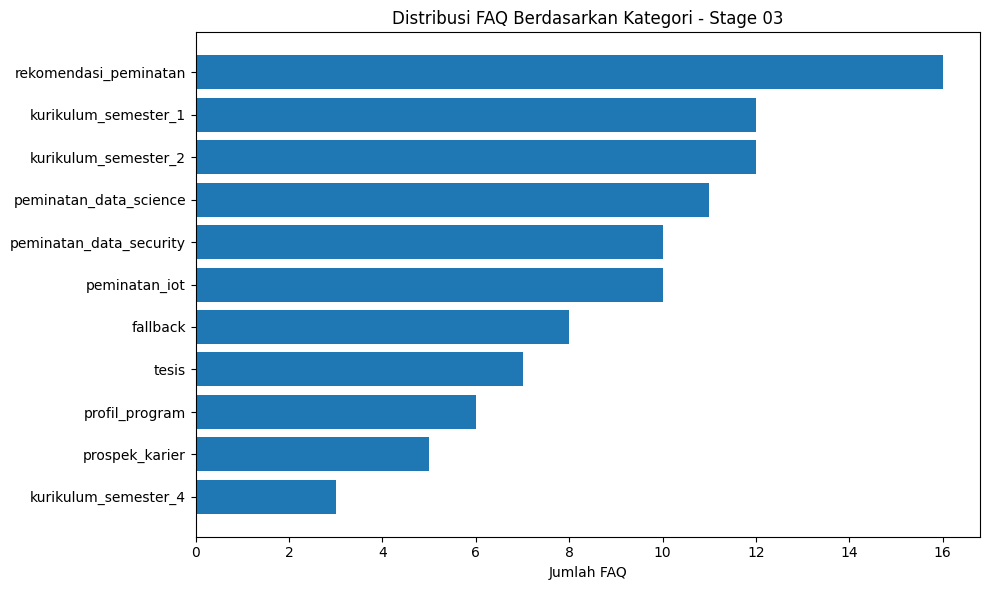

In [12]:
# 1. Distribusi FAQ berdasarkan kategori
plt.figure(figsize=(10, 6))
cat_counts = faq_df["category"].value_counts().sort_values()
plt.barh(cat_counts.index, cat_counts.values)
plt.title("Distribusi FAQ Berdasarkan Kategori - Stage 03")
plt.xlabel("Jumlah FAQ")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_faq_category_distribution_stage03.png", dpi=200)
plt.show()

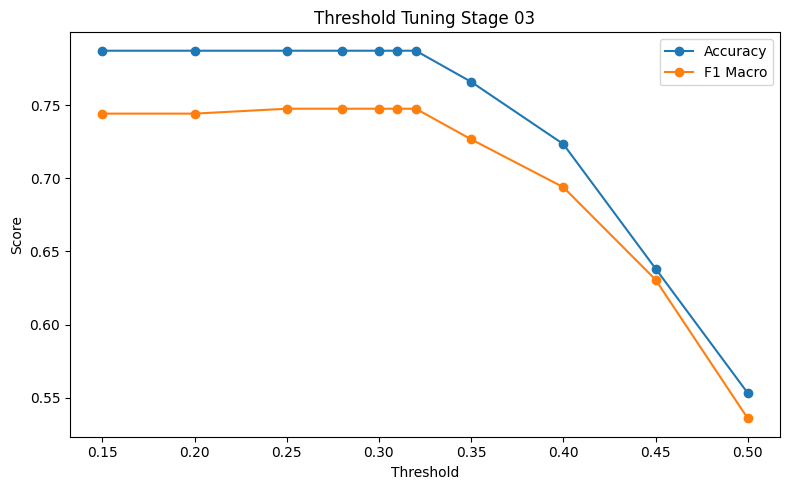

In [13]:
# 2. Threshold tuning
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], marker="o", label="Accuracy")
plt.plot(threshold_df["threshold"], threshold_df["f1_macro"], marker="o", label="F1 Macro")
plt.title("Threshold Tuning Stage 03")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_threshold_tuning_stage03.png", dpi=200)
plt.show()

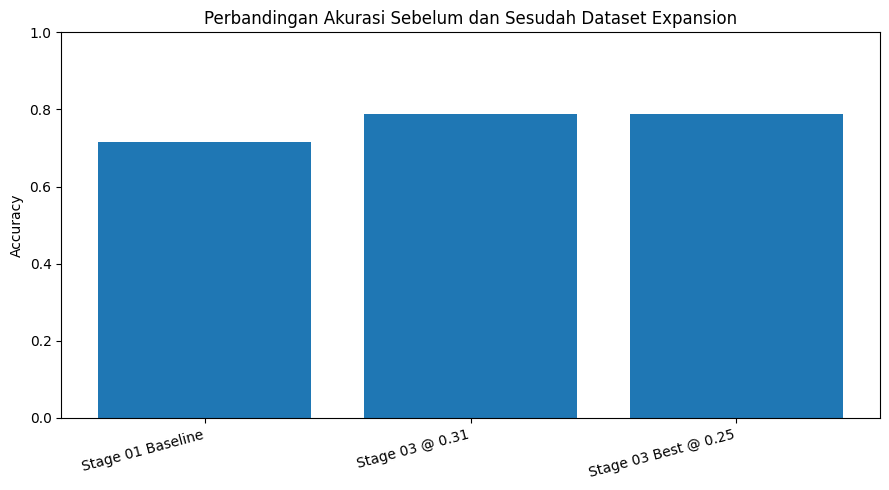

,stage,accuracy
0,Stage 01 Baseline,0.714300
1,Stage 03 @ 0.31,0.787234
2,Stage 03 Best @ 0.25,0.787234


In [14]:
# 3. Perbandingan akurasi baseline vs stage 03
best_row = threshold_df.sort_values(["accuracy", "f1_macro"], ascending=False).iloc[0]
comparison_df = pd.DataFrame([
    {"stage": "Stage 01 Baseline", "accuracy": 0.7143},
    {"stage": "Stage 03 @ 0.31", "accuracy": accuracy_031},
    {"stage": f"Stage 03 Best @ {best_row['threshold']:.2f}", "accuracy": best_row["accuracy"]},
])

plt.figure(figsize=(9, 5))
plt.bar(comparison_df["stage"], comparison_df["accuracy"])
plt.ylim(0, 1)
plt.title("Perbandingan Akurasi Sebelum dan Sesudah Dataset Expansion")
plt.ylabel("Accuracy")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_accuracy_comparison_stage03.png", dpi=200)
plt.show()

comparison_df

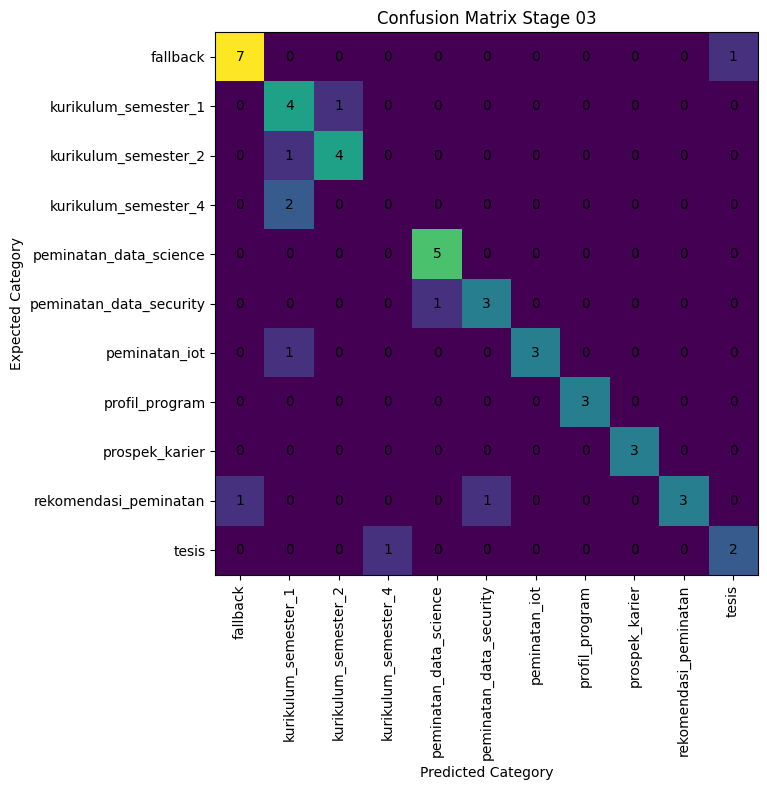

In [15]:
# 4. Confusion matrix pada best threshold
best_threshold = float(best_row["threshold"])
eval_result_best = evaluate_questions(eval_df, threshold=best_threshold)
labels = sorted(set(eval_result_best["expected_category"]) | set(eval_result_best["predicted_category"]))
cm = confusion_matrix(eval_result_best["expected_category"], eval_result_best["predicted_category"], labels=labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix Stage 03")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted Category")
plt.ylabel("Expected Category")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_confusion_matrix_stage03.png", dpi=200)
plt.show()

## 9. Error Analysis

Error analysis digunakan untuk melihat pertanyaan mana yang masih salah prediksi dan perlu diperbaiki pada tahap berikutnya.

In [16]:
error_df = eval_result_best[~eval_result_best["is_correct"]].copy()
print("Total error:", len(error_df))
error_df[["test_question", "expected_category", "predicted_category", "similarity_score", "matched_question"]]

Total error: 10


,test_question,expected_category,predicted_category,similarity_score,matched_question
0,Mata kuliah semester satu apa saja?,kurikulum_semester_1,kurikulum_semester_2,0.5234,Apa saja mata kuliah Semester 2 MTI UNPAM?
6,Statistik dan analisis data itu penting untuk ...,kurikulum_semester_2,kurikulum_semester_1,0.3957,Mengapa Algoritma Analisis penting untuk mahas...
15,Saya suka cyber security cocoknya peminatan apa?,rekomendasi_peminatan,peminatan_data_security,0.4893,Apa yang dipelajari pada Cyber Security?
19,Saya masih bingung memilih peminatan,rekomendasi_peminatan,fallback,0.2064,Bagaimana cara memilih topik tesis MTI?
20,Apa saja mata kuliah Data Security?,peminatan_data_security,peminatan_data_science,0.6841,Apa saja mata kuliah peminatan Data Science?
26,Apa hubungan IoT dengan machine learning?,peminatan_iot,kurikulum_semester_1,0.7466,Apa hubungan Data Mining dengan machine learning?
28,Semester empat ada mata kuliah apa?,kurikulum_semester_4,kurikulum_semester_1,0.4461,Mata kuliah apa yang paling dekat dengan Data ...
29,Technopreneurship membahas apa?,kurikulum_semester_4,kurikulum_semester_1,0.4104,Semester satu MTI UNPAM membahas apa saja?
30,Tesis itu apa di semester 4?,tesis,kurikulum_semester_4,0.3661,Apakah Semester 4 hanya berisi tesis?
46,Bagaimana cara memperbaiki motor mogok?,fallback,tesis,0.5405,Bagaimana cara memilih topik tesis MTI?


## 10. Export Output Tahap 03

Seluruh hasil evaluasi dan ringkasan disimpan ke folder `outputs/stage03/` agar siap dilampirkan atau di-push ke GitHub.

In [17]:
threshold_df.to_csv(OUTPUT_DIR / "threshold_tuning_results_stage03.csv", index=False)
eval_result_031.to_csv(OUTPUT_DIR / "evaluation_result_threshold_0_31_stage03.csv", index=False)
eval_result_best.to_csv(OUTPUT_DIR / "evaluation_result_best_threshold_stage03.csv", index=False)

summary_df = pd.DataFrame([
    {"metric": "faq_rows_stage03", "value": len(faq_df)},
    {"metric": "faq_categories_stage03", "value": faq_df["category"].nunique()},
    {"metric": "evaluation_rows_stage03", "value": len(eval_df)},
    {"metric": "tfidf_matrix_rows_stage03", "value": tfidf_matrix.shape[0]},
    {"metric": "tfidf_matrix_features_stage03", "value": tfidf_matrix.shape[1]},
    {"metric": "baseline_accuracy_stage01", "value": "71.43%"},
    {"metric": "stage02_recommended_threshold", "value": "0.31"},
    {"metric": "stage03_accuracy_at_0_31", "value": f"{accuracy_031:.2%}"},
    {"metric": "stage03_best_threshold", "value": best_threshold},
    {"metric": "stage03_accuracy_at_best_threshold", "value": f"{best_row['accuracy']:.2%}"},
])

summary_df.to_csv(OUTPUT_DIR / "stage03_improvement_summary.csv", index=False)
summary_df

,metric,value
0,faq_rows_stage03,100
1,faq_categories_stage03,11
2,evaluation_rows_stage03,47
3,tfidf_matrix_rows_stage03,100
4,tfidf_matrix_features_stage03,570
5,baseline_accuracy_stage01,71.43%
6,stage02_recommended_threshold,0.31
7,stage03_accuracy_at_0_31,78.72%
8,stage03_best_threshold,0.25
9,stage03_accuracy_at_best_threshold,78.72%


## 11. Kesimpulan Tahap 03

Dataset expansion meningkatkan cakupan pertanyaan chatbot, memperbanyak variasi parafrase, dan memperkuat fallback untuk pertanyaan di luar konteks. Evaluasi ulang dilakukan dengan jumlah pertanyaan uji yang lebih representatif. Hasil tahap ini menjadi dasar untuk tahap berikutnya, yaitu finalisasi aplikasi Streamlit, dokumentasi GitHub, dan deployment.